In [1]:
# !pip install pandas
# !pip install matplotlib seaborn numpy
# !pip install emoji

In [2]:
import json
from pathlib import Path

import re
import emoji
import pandas as pd

### Extracting only the "TEXT" field in the dataset (p. 1 to 7)

In [3]:
from pathlib import Path

DATASET_DIR = Path('dataset')

all_text_df = pd.read_csv('dataset/dataset_twitter-scraper_2025-09-29_13-34-09-436.csv')

In [4]:
all_text_df.sample()

,text
945,Ke di emetse


In [5]:
# Pre-clean snapshot
pre_count_total = len(all_text_df)
pre_count_null = int(all_text_df['text'].isna().sum())
pre_count_empty = int((all_text_df['text'].astype(str).str.strip() == '').sum())

print(
    f"Total records: {pre_count_total}\n"
    f"Null records: {pre_count_null}\n"
    f"Empty records: {pre_count_empty}\n"
)

Total records: 3524
Null records: 0
Empty records: 0



### Duplicate, Null, and Empty String removal

In [6]:
clean_df = all_text_df.copy()
clean_df['text'] = clean_df['text'].astype(str).str.strip()

# Identify removals before dropping
stripped_all = all_text_df['text'].astype(str).str.strip()
is_empty = stripped_all == ''
is_nan_literal = stripped_all.str.lower().eq('nan')
removed_empty = int(is_empty.sum())
removed_nan_literal = int(is_nan_literal.sum())
removed_nulls = int(all_text_df['text'].isna().sum())

# Apply cleaning steps
clean_df = clean_df.replace({'text': {'nan': ''}})
clean_df = clean_df.dropna(subset=['text'])
clean_df = clean_df[clean_df['text'] != '']

# Duplicates among keepable rows before de-dup
keepable_mask = (~is_empty) & (~is_nan_literal)
duplicates_removed = int(stripped_all[keepable_mask].duplicated(keep='first').sum())
clean_df = clean_df.drop_duplicates(subset=['text'], keep='first')

# Post-clean stats
post_count_total = len(clean_df)

# Summary including removals
summary_df = pd.DataFrame({
    'metric': [
        'total_records_pre',
        'total_records_post',
        'removed_nulls',
        'removed_empty_strings',
        "removed_literal_'nan'_strings",
        'removed_duplicates'
    ],
    'count': [
        pre_count_total,
        post_count_total,
        removed_nulls,
        removed_empty,
        removed_nan_literal,
        duplicates_removed
    ]
})
summary_df

,metric,count
0,total_records_pre,3524
1,total_records_post,3519
2,removed_nulls,0
3,removed_empty_strings,0
4,removed_literal_'nan'_strings,0
5,removed_duplicates,5


C:\Users\Reejay Salinas\AppData\Local\Temp\ipykernel_22232\262463332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x='stage', y='records', palette=['#6baed6', '#31a354'])


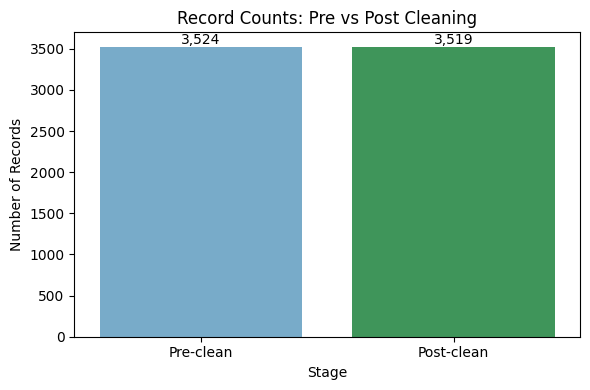

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = pd.DataFrame({
    'stage': ['Pre-clean', 'Post-clean'],
    'records': [pre_count_total, post_count_total]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=counts, x='stage', y='records', palette=['#6baed6', '#31a354'])
plt.title('Record Counts: Pre vs Post Cleaning')
plt.xlabel('Stage')
plt.ylabel('Number of Records')
for index, value in enumerate(counts['records']):
    plt.text(index, value, f"{value:,}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

C:\Users\Reejay Salinas\AppData\Local\Temp\ipykernel_22232\124699484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=removals, x='category', y='removed', palette=['#fd8d3c', '#fdbb84', '#fdd49e', '#3182bd'])


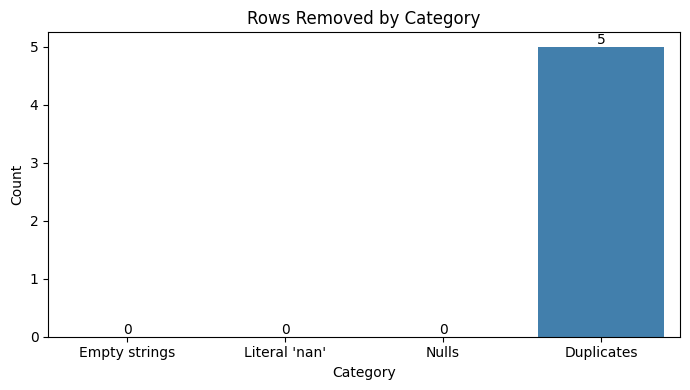

In [8]:
# Removals bar chart
removals = pd.DataFrame({
    'category': ['Empty strings', "Literal 'nan'", 'Nulls', 'Duplicates'],
    'removed': [removed_empty, removed_nan_literal, removed_nulls, duplicates_removed]
})

plt.figure(figsize=(7, 4))
sns.barplot(data=removals, x='category', y='removed', palette=['#fd8d3c', '#fdbb84', '#fdd49e', '#3182bd'])
plt.title('Rows Removed by Category')
plt.xlabel('Category')
plt.ylabel('Count')
for index, value in enumerate(removals['removed']):
    plt.text(index, value, f"{value:,}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Artifact removal (URLs, mentions, hashtags, emojis) with counts and chart

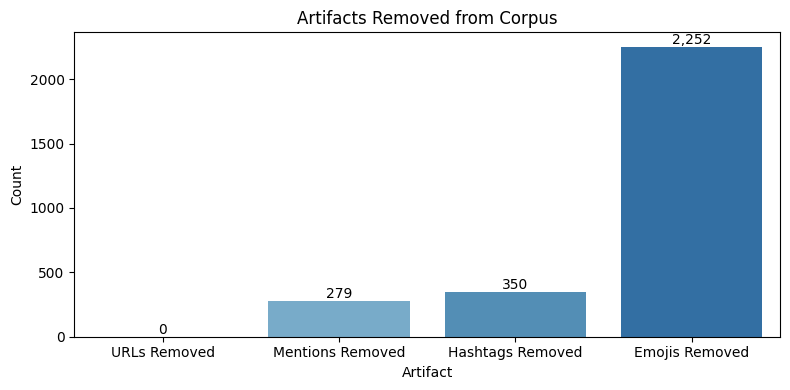

In [9]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Patterns
url_pattern = r'(https?://\S+|www\.\S+)'
mention_pattern = r'@[A-Za-z0-9_]+'
hashtag_pattern = r'#([A-Za-z0-9_]+)'

# Counts before removal
urls_removed = int(clean_df['text'].str.count(url_pattern).sum())
mentions_removed = int(clean_df['text'].str.count(mention_pattern).sum())
hashtags_removed = int(clean_df['text'].str.count(hashtag_pattern).sum())
# Count emojis with the emoji library
emojis_removed = int(clean_df['text'].apply(lambda s: len(emoji.emoji_list(str(s)))).sum())

# Apply removals (preserve hashtag words as plain tokens) with emoji.replace_emoji
clean_df['text'] = (
    clean_df['text']
        .str.replace(url_pattern, ' ', regex=True)
        .str.replace(mention_pattern, ' ', regex=True)
        .str.replace(hashtag_pattern, r'\1', regex=True)
        .apply(lambda s: emoji.replace_emoji(str(s), replace=' '))
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
)

# Drop any rows that became empty after artifact removal
clean_df = clean_df[clean_df['text'] != '']

# Store counts in a dataframe
artifact_counts_df = pd.DataFrame({
    'artifact': ['URLs Removed', 'Mentions Removed', 'Hashtags Removed', 'Emojis Removed'],
    'count': [urls_removed, mentions_removed, hashtags_removed, emojis_removed]
})

# Visualize artifact removals
plt.figure(figsize=(8, 4))
sns.barplot(data=artifact_counts_df, x='artifact', y='count', hue='artifact', dodge=False, legend=False,
            palette=['#9ecae1', '#6baed6', '#4292c6', '#2171b5'])
plt.title('Artifacts Removed from Corpus')
plt.xlabel('Artifact')
plt.ylabel('Count')
for idx, val in enumerate(artifact_counts_df['count']):
    plt.text(idx, val, f"{val:,}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [10]:
clean_output_path = Path('extracted_cleaned_tweets.csv')
clean_df.to_csv(clean_output_path, index=False, encoding='utf-8')
print(f"Saved cleaned dataset with {len(clean_df):,} rows to {clean_output_path}")

Saved cleaned dataset with 3,504 rows to extracted_cleaned_tweets.csv
